In [1]:
import pandas as pd 

import matplotlib.pyplot as plt 

import seaborn as sns 

 

df = pd.read_csv('../data/cleaned_data.csv') 

sns.set_theme(style='darkgrid') 

plt.rcParams['figure.figsize'] = (12, 6) 

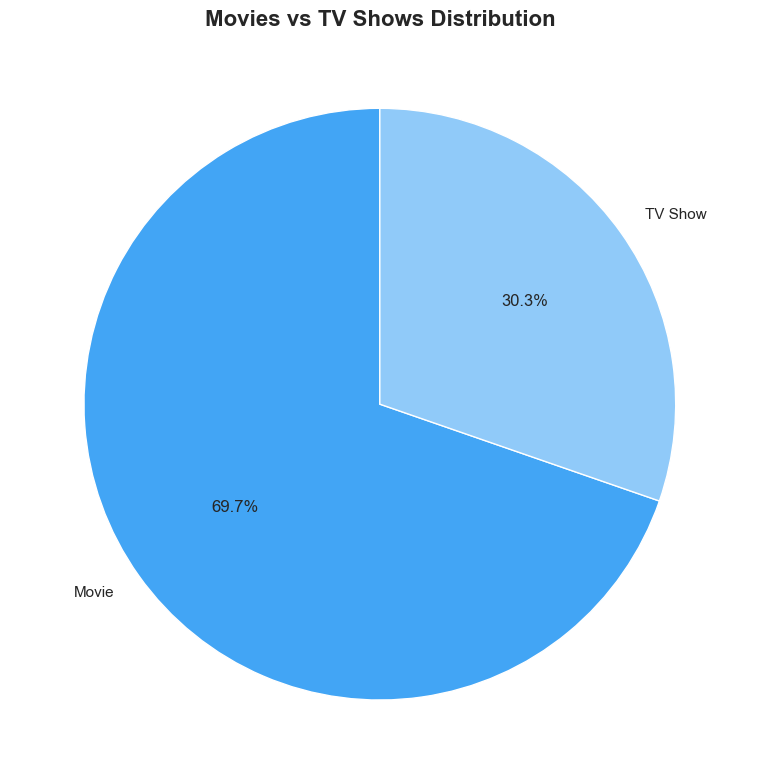

In [57]:
# Chart 1: Content Type Distribution
content_type = df['type'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#42A5F5', '#90CAF9']
plt.pie(content_type.values, labels=content_type.index,
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Movies vs TV Shows Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_content_type.png', dpi=150)
plt.show()

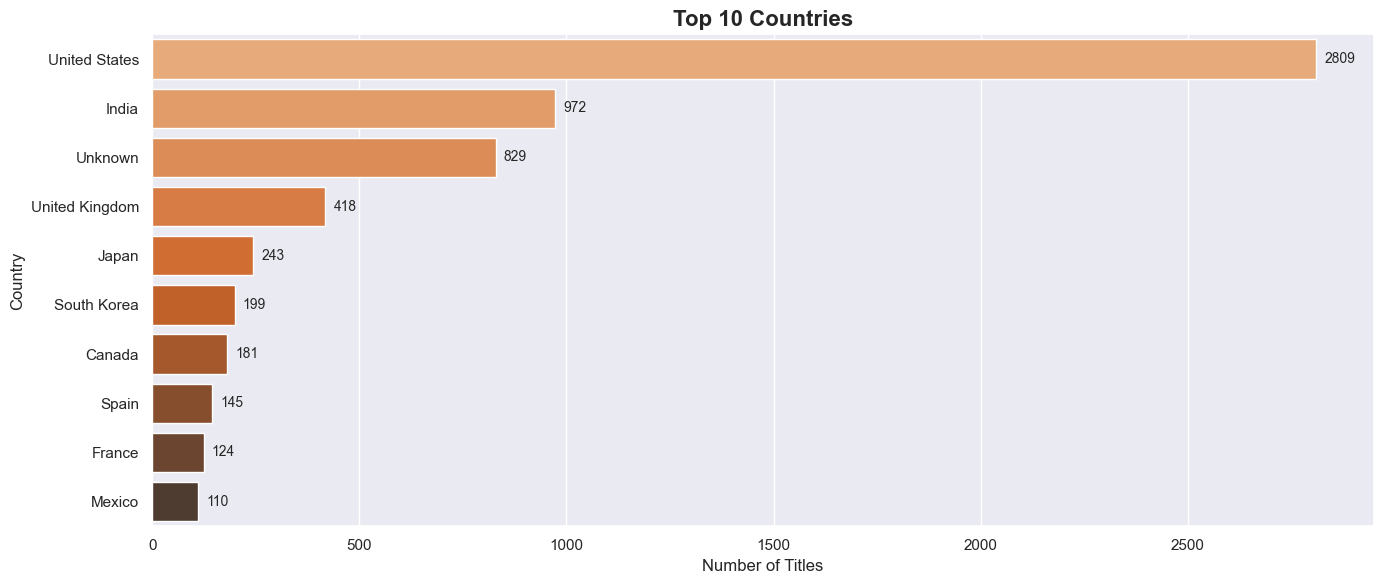

In [55]:
# Chart 2: Top 10 Countries
countries = df['country'].value_counts().head(10)

plt.figure(figsize=(14, 6))
bars = sns.barplot(x=countries.values, y=countries.index,
                   hue=countries.index, palette='Oranges_d', legend=False)

for bar, value in zip(bars.patches, countries.values):
    bars.text(bar.get_width() + 20,
              bar.get_y() + bar.get_height()/2,
              str(value), va='center', fontsize=10)

plt.title('Top 10 Countries', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/02_top_countries.png', dpi=150)
plt.show()

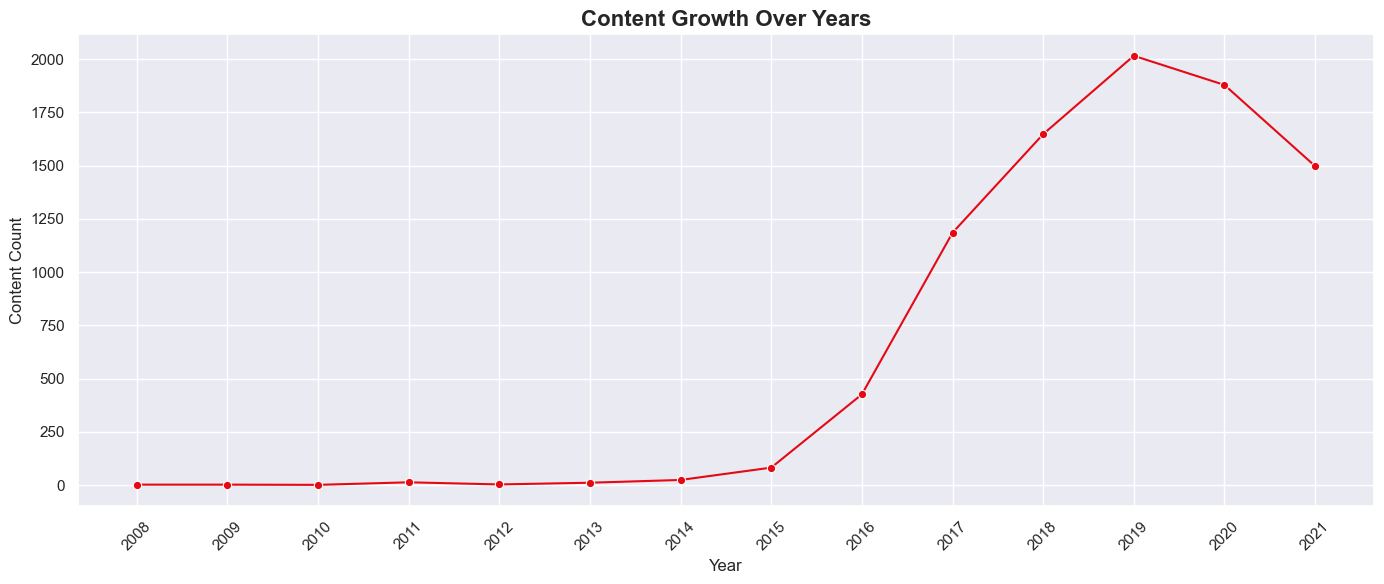

In [56]:
# Chart 3: Content Growth Over Years
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
content_years = df['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x=content_years.index, y=content_years.values, marker='o', color='#E50914')
plt.title('Content Growth Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Content Count', fontsize=12)
plt.xticks(content_years.index, rotation=45)
plt.tight_layout()
plt.savefig('../reports/03_content_growth.png', dpi=150)
plt.show()

In [29]:
df = df[~df['rating'].str.contains('min')]

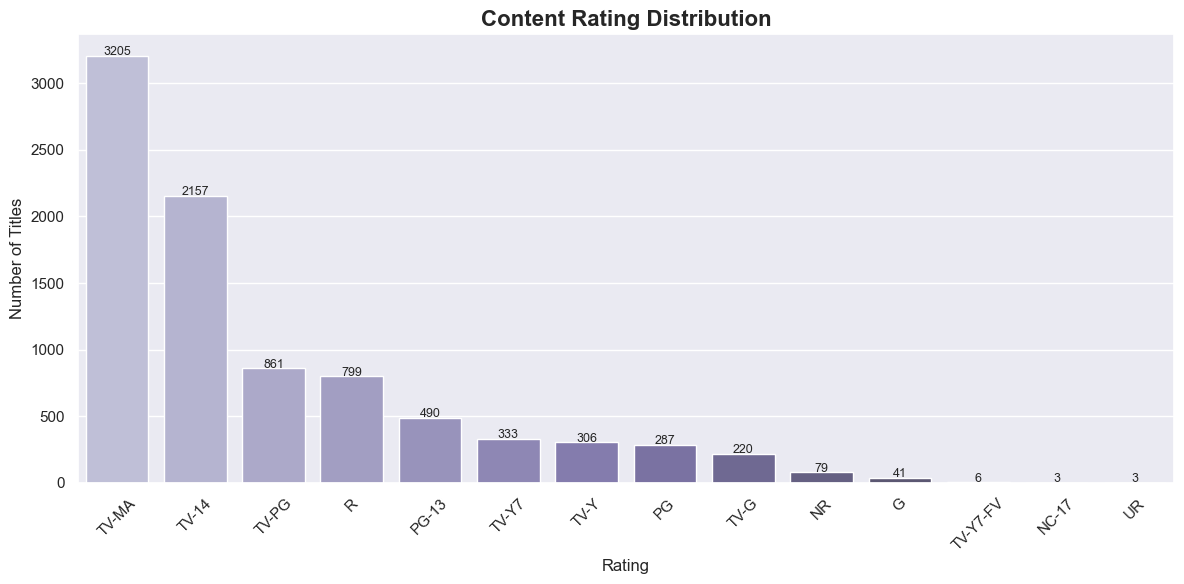

In [48]:
ratings = df['rating'].value_counts()

plt.figure()
bars = sns.barplot(x=ratings.index, y=ratings.values,
                   hue=ratings.index, palette='Purples_d', legend=False)

for bar, value in zip(bars.patches, ratings.values):
    bars.text(bar.get_x() + bar.get_width()/2,
          bar.get_height() + 5,
          str(value),
          ha='center', fontsize=9)

plt.title('Content Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/04_rating_distribution.png', dpi=150)
plt.show()

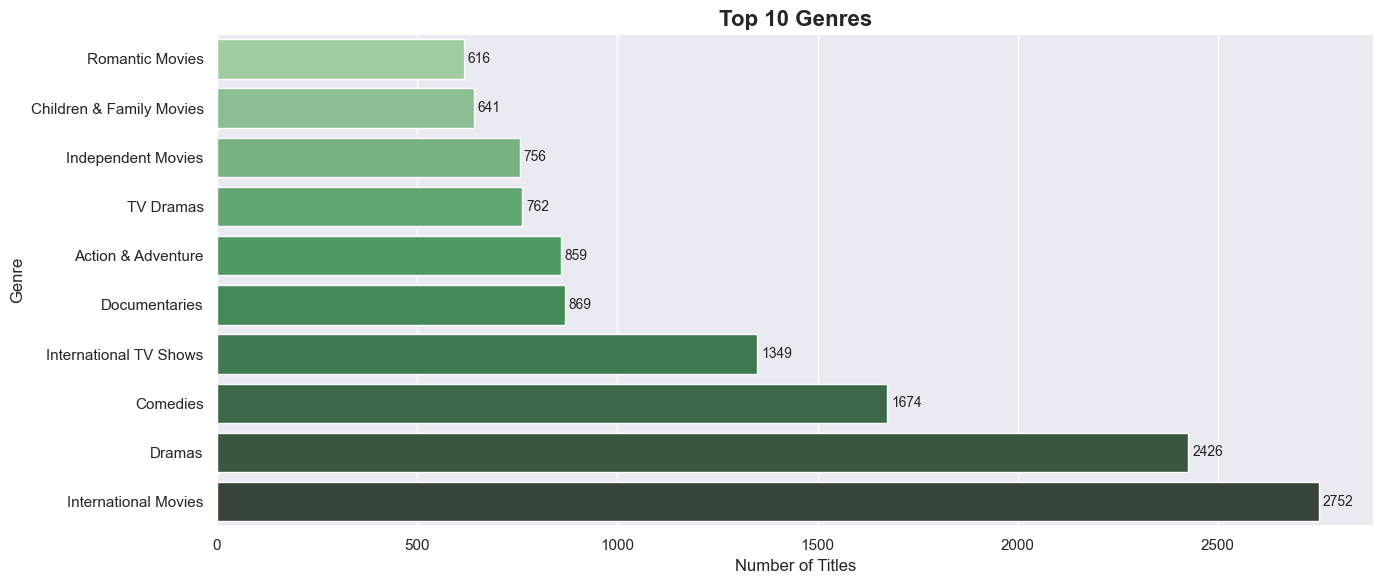

In [49]:
# Split genres and count
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(14, 6))
bars = sns.barplot(x=genres.values, y=genres.index,
                   hue=genres.index, palette='Greens_d', legend=False)

for bar, value in zip(bars.patches, genres.values):
    bars.text(bar.get_width() + 10,
              bar.get_y() + bar.get_height()/2,
              str(value),
              va='center', fontsize=10)

plt.title('Top 10 Genres', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/05_top_genres.png', dpi=150)
plt.show()